# MovieLens EDA + pipeline + API

Ce notebook est maintenant executable de bout en bout sur Colab.
Il couvre:
- le setup Colab (repo, Java, dependances)
- l'EDA de base sur MovieLens
- l'equivalent de `scripts/run_pipeline.py`
- le test de l'API FastAPI sans quitter le notebook


## 0) Setup Colab

Cette cellule detecte Colab, clone le repo si besoin, installe Java 17 et les dependances Python.
En local, elle se contente de se replacer a la racine du projet.


In [1]:
import os
import shutil
import subprocess
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/younesda/recommandation_film.git"
REPO_DIR = Path("/content/recommandation_film") if IN_COLAB else Path.cwd()

if IN_COLAB:
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
    os.chdir(REPO_DIR)

    java_home = Path("/usr/lib/jvm/java-17-openjdk-amd64")
    java_bin = java_home / "bin" / "java"
    if not java_bin.exists():
        subprocess.run(["apt-get", "-qq", "update"], check=True)
        subprocess.run(["apt-get", "-qq", "install", "-y", "openjdk-17-jdk-headless"], check=True)

    os.environ["JAVA_HOME"] = str(java_home)
    os.environ["PATH"] = f"{java_home / 'bin'}:{os.environ['PATH']}"
    os.environ.setdefault("SPARK_DRIVER_MEMORY", "6g")
    os.environ.setdefault("SPARK_EXECUTOR_MEMORY", "6g")

    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    candidates = [Path.cwd(), *Path.cwd().parents]
    repo_root = next(
        (path for path in candidates if (path / "src").exists() and (path / "requirements.txt").exists()),
        Path.cwd(),
    )
    os.chdir(repo_root)
    REPO_DIR = repo_root

print(f"IN_COLAB={IN_COLAB}")
print(f"REPO_DIR={REPO_DIR}")
print(f"PYTHON={sys.executable}")
print(f"JAVA={shutil.which('java')}")
print(f"SPARK_DRIVER_MEMORY={os.environ.get('SPARK_DRIVER_MEMORY', 'default')}")
print(f"SPARK_EXECUTOR_MEMORY={os.environ.get('SPARK_EXECUTOR_MEMORY', 'default')}")


IN_COLAB=True
REPO_DIR=/content/recommandation_film
PYTHON=/usr/bin/python3
JAVA=/usr/lib/jvm/java-17-openjdk-amd64/bin/java
SPARK_DRIVER_MEMORY=6g
SPARK_EXECUTOR_MEMORY=6g


## 1) Imports et config projet

On charge les modules du repo et on prepare quelques reglages d'affichage.


In [2]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from fastapi.testclient import TestClient
from IPython.display import display

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.api.main import APP
from src.config.settings import ALSSettings, DataPaths, HybridSettings, PipelineSettings
from src.ingestion.load_data import load_all_data
from src.pipelines.training_pipeline import run_pipeline
from src.preprocessing.clean_data import clean_movies, clean_ratings, clean_tags, time_based_split
from src.preprocessing.feature_engineering import add_time_features, build_movie_genre_weights, encode_genres
from src.preprocessing.spark_session import create_spark
from src.preprocessing.user_profiles import create_user_profiles
from src.utils.logging_utils import configure_logging

configure_logging("INFO")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)


## 2) Parametres du run

Cette cellule remplace les arguments CLI de `scripts/run_pipeline.py`.
Vous pouvez ajuster `TOP_K`, les chemins ou les seuils avant de lancer le pipeline.


In [3]:
DATA_DIR = ROOT / "data" / "raw"
OUTPUT_BASE = ROOT / "data" / "processed"
TOP_K = 10
USE_TAGS = True

settings = PipelineSettings(
    shuffle_partitions=16,
    min_user_interactions=20,
    min_item_interactions=5,
    data_paths=DataPaths(
        ratings=str(DATA_DIR / "ratings.csv"),
        movies=str(DATA_DIR / "movies.csv"),
        tags=str(DATA_DIR / "tags.csv"),
        raw_parquet_base=str(OUTPUT_BASE / "parquet" / "raw"),
        output_base=str(OUTPUT_BASE),
    ),
    hybrid=HybridSettings(top_k=TOP_K),
    als=ALSSettings(),
)

artifacts = {
    "recommendations_path": str(OUTPUT_BASE / "recommendations"),
    "metrics_path": str(OUTPUT_BASE / "metrics" / "metrics.json"),
    "seen_interactions_path": str(OUTPUT_BASE / "seen_interactions"),
}

display(
    pd.DataFrame(
        [
            {"param": "ratings", "value": settings.data_paths.ratings},
            {"param": "movies", "value": settings.data_paths.movies},
            {"param": "tags", "value": settings.data_paths.tags},
            {"param": "output_base", "value": settings.data_paths.output_base},
            {"param": "top_k", "value": settings.hybrid.top_k},
            {"param": "use_tags", "value": USE_TAGS},
        ]
    )
)


,param,value
0,ratings,/content/recommandation_film/data/raw/ratings.csv
1,movies,/content/recommandation_film/data/raw/movies.csv
2,tags,/content/recommandation_film/data/raw/tags.csv
3,output_base,/content/recommandation_film/data/processed
4,top_k,10
5,use_tags,True


## 3) Creation de la session Spark


In [4]:
spark = create_spark(settings=settings)
spark


## 4) Chargement des donnees brutes

On charge les CSV MovieLens pour l'analyse exploratoire.


In [5]:
ratings_raw, movies_raw, tags_raw = load_all_data(spark=spark, settings=settings, prefer_parquet=False)

raw_summary = pd.DataFrame(
    [
        {"table": "ratings_raw", "rows": ratings_raw.count(), "cols": len(ratings_raw.columns)},
        {"table": "movies_raw", "rows": movies_raw.count(), "cols": len(movies_raw.columns)},
        {"table": "tags_raw", "rows": tags_raw.count(), "cols": len(tags_raw.columns)},
    ]
)
display(raw_summary)
ratings_raw.show(5, truncate=False)
movies_raw.show(5, truncate=False)
tags_raw.show(5, truncate=False)


,table,rows,cols
0,ratings_raw,100836,4
1,movies_raw,9742,3
2,tags_raw,3683,4


+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|1     |1      |4.0   |964982703|
|1     |3      |4.0   |964981247|
|1     |6      |4.0   |964982224|
|1     |47     |5.0   |964983815|
|1     |50     |5.0   |964982931|
+------+-------+------+---------+
only showing top 5 rows
+-------+----------------------------------+-------------------------------------------+
|movieId|title                             |genres                                     |
+-------+----------------------------------+-------------------------------------------+
|1      |Toy Story (1995)                  |Adventure|Animation|Children|Comedy|Fantasy|
|2      |Jumanji (1995)                    |Adventure|Children|Fantasy                 |
|3      |Grumpier Old Men (1995)           |Comedy|Romance                             |
|4      |Waiting to Exhale (1995)          |Comedy|Drama|Romance                       |
|5      |Father of the Bride Part II (1995)|Com

## 5) Pretraitement et vue globale

On applique les memes briques que dans le pipeline pour obtenir des donnees propres, des features temporelles et les splits train/val/test.


In [6]:
movies_clean = clean_movies(movies_raw).cache()
tags_clean = clean_tags(tags_raw).cache()
ratings_clean = clean_ratings(ratings_raw, settings=settings).cache()
ratings_feat = add_time_features(ratings_clean).cache()

movie_genres = encode_genres(movies_clean).cache()
movie_genre_weights = build_movie_genre_weights(movie_genres).cache()
user_profiles = create_user_profiles(ratings_feat).cache()

train_df, val_df, test_df = time_based_split(ratings_feat, settings=settings)
train_df = train_df.cache()
val_df = val_df.cache()
test_df = test_df.cache()

prep_summary = pd.DataFrame(
    [
        {"dataset": "ratings_clean", "rows": ratings_clean.count()},
        {"dataset": "movies_clean", "rows": movies_clean.count()},
        {"dataset": "tags_clean", "rows": tags_clean.count()},
        {"dataset": "user_profiles", "rows": user_profiles.count()},
        {"dataset": "train_df", "rows": train_df.count()},
        {"dataset": "val_df", "rows": val_df.count()},
        {"dataset": "test_df", "rows": test_df.count()},
    ]
)
display(prep_summary)


,dataset,rows
0,ratings_clean,85980
1,movies_clean,9742
2,tags_clean,3683
3,user_profiles,590
4,train_df,68787
5,val_df,8517
6,test_df,8676


## 6) EDA rapide

On passe en pandas pour quelques visualisations simples sur ce jeu MovieLens.


In [7]:
ratings_pd = ratings_clean.select("userId", "movieId", "rating", "timestamp").toPandas()
ratings_pd["datetime"] = pd.to_datetime(ratings_pd["timestamp"], unit="s")

movies_pd = movies_clean.select("movieId", "title", "genres").toPandas()
ratings_per_user = ratings_pd.groupby("userId").size().rename("n_ratings")
ratings_per_movie = ratings_pd.groupby("movieId").size().rename("n_ratings")
monthly_activity = ratings_pd.set_index("datetime").resample("M").size().rename("n_ratings")
genre_counts = (
    movies_pd.assign(genre=movies_pd["genres"].str.split("|"))
    .explode("genre")
    .groupby("genre")
    .size()
    .sort_values(ascending=False)
)

display(
    pd.DataFrame(
        [
            {"metric": "n_users", "value": ratings_pd["userId"].nunique()},
            {"metric": "n_movies", "value": ratings_pd["movieId"].nunique()},
            {"metric": "n_ratings", "value": len(ratings_pd)},
            {"metric": "avg_ratings_per_user", "value": round(float(ratings_per_user.mean()), 2)},
            {"metric": "avg_ratings_per_movie", "value": round(float(ratings_per_movie.mean()), 2)},
        ]
    )
)


/tmp/ipykernel_1788/1432201518.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_activity = ratings_pd.set_index("datetime").resample("M").size().rename("n_ratings")


,metric,value
0,n_users,590.00
1,n_movies,3514.00
2,n_ratings,85980.00
3,avg_ratings_per_user,145.73
4,avg_ratings_per_movie,24.47


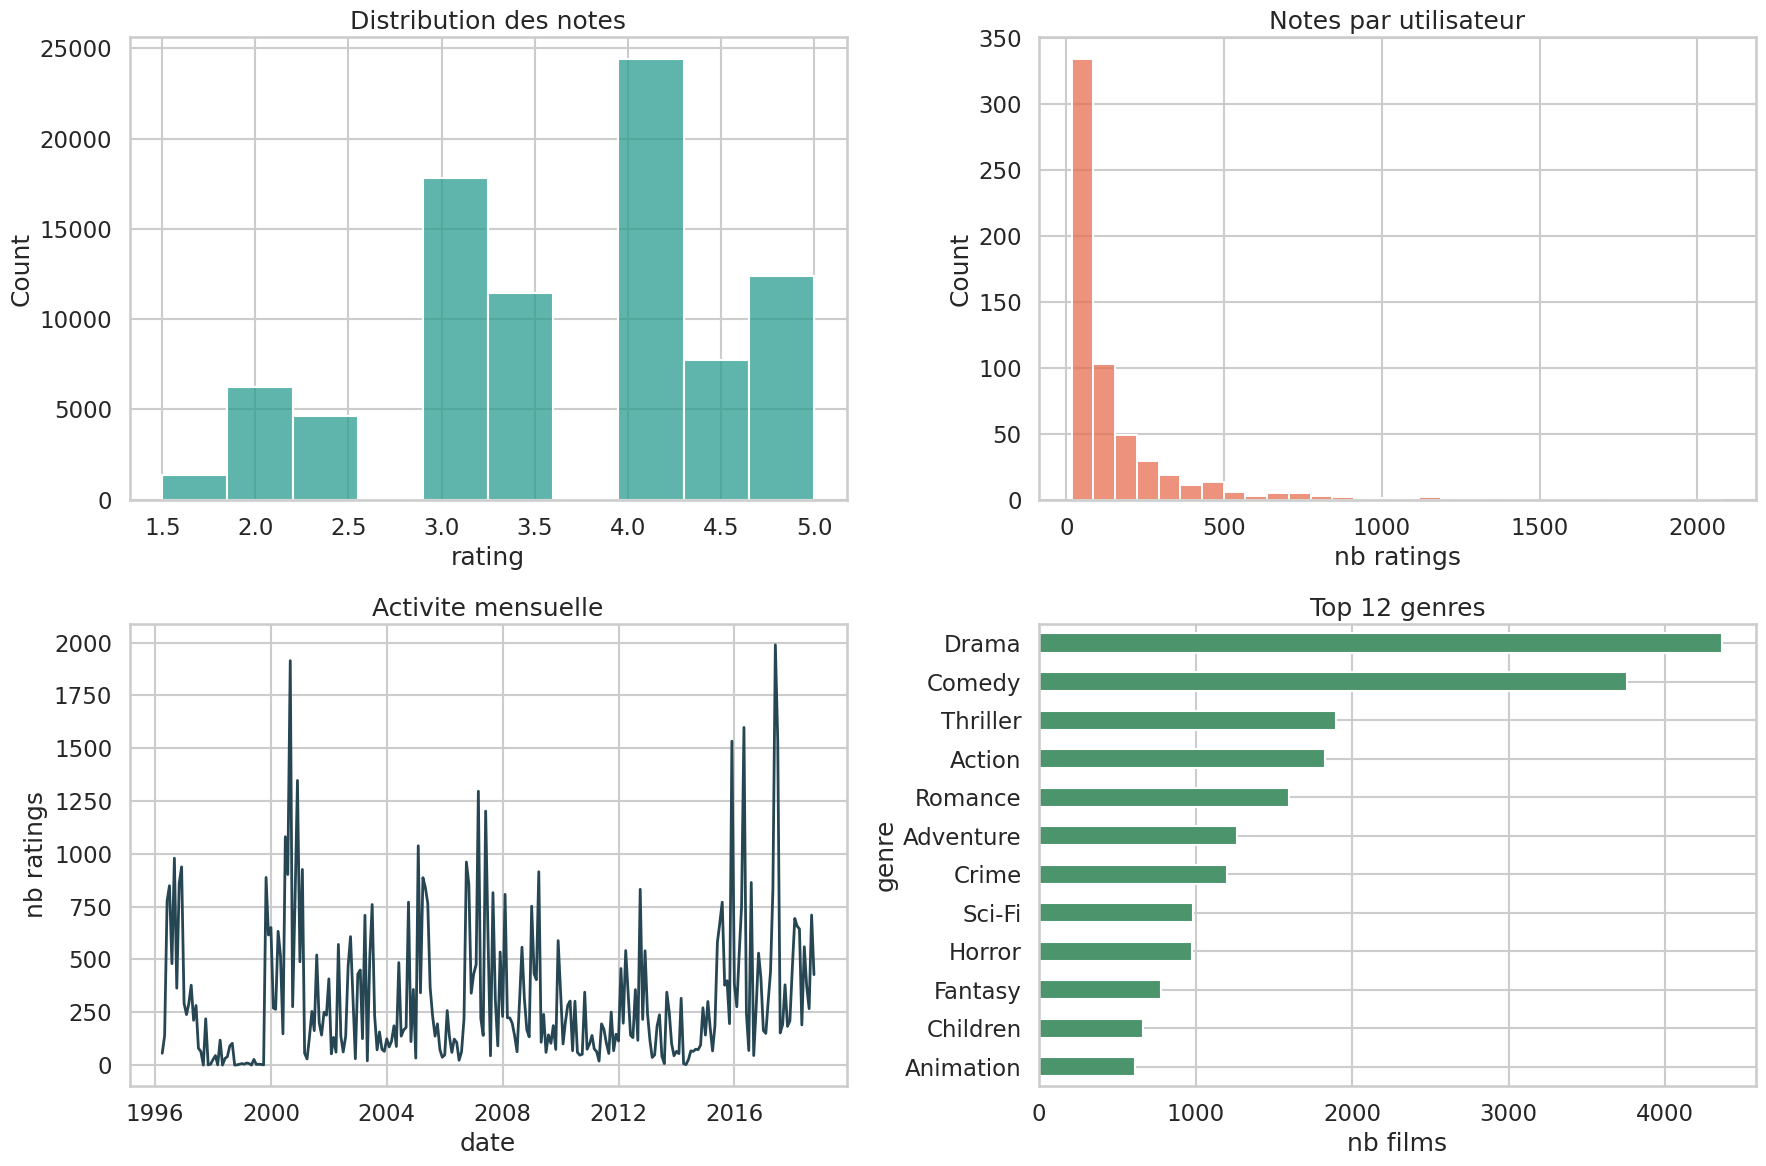

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.histplot(ratings_pd["rating"], bins=10, color="#2A9D8F", ax=axes[0, 0])
axes[0, 0].set_title("Distribution des notes")
axes[0, 0].set_xlabel("rating")

sns.histplot(ratings_per_user, bins=30, color="#E76F51", ax=axes[0, 1])
axes[0, 1].set_title("Notes par utilisateur")
axes[0, 1].set_xlabel("nb ratings")

axes[1, 0].plot(monthly_activity.index, monthly_activity.values, color="#264653", linewidth=2)
axes[1, 0].set_title("Activite mensuelle")
axes[1, 0].set_xlabel("date")
axes[1, 0].set_ylabel("nb ratings")

genre_counts.head(12).sort_values().plot(kind="barh", color="#4C956C", ax=axes[1, 1])
axes[1, 1].set_title("Top 12 genres")
axes[1, 1].set_xlabel("nb films")

plt.tight_layout()
plt.show()


## 7) Pipeline complet

Cette cellule est l'equivalent notebook de `scripts/run_pipeline.py`.
Elle entraine le modele hybride, calcule les metriques et sauvegarde les artefacts dans `data/processed`.


In [10]:
pipeline_result = run_pipeline(spark=spark, settings=settings, use_tags=USE_TAGS)
display(pd.DataFrame([pipeline_result]).T.rename(columns={0: "value"}))


,value
recommendations_path,/content/recommandation_film/data/processed/re...
metrics_path,/content/recommandation_film/data/processed/me...
rmse,0.763626
mae,0.604764
precision_at_10,0.01
recall_at_10,0.017365
ndcg_at_10,0.015902
hybrid_als_weight,0.5
hybrid_content_weight,0.5
val_precision_at_k,0.007504


## 8) Verification des artefacts generes

On recharge les sorties produites par le pipeline pour verifier rapidement les metriques et les recommandations exportees.


In [11]:
with open(artifacts["metrics_path"], "r", encoding="utf-8") as file:
    metrics = json.load(file)

metrics_df = (
    pd.DataFrame(
        [{"metric": key, "value": value} for key, value in metrics.items()]
    )
    .sort_values("metric")
    .reset_index(drop=True)
)
recs_df = pd.read_parquet(artifacts["recommendations_path"]).sort_values(["userId", "rank"])

display(metrics_df)
display(recs_df.head(15))


,metric,value
0,active_movies,9742.000000
1,active_users,590.000000
2,als_max_iter,10.000000
3,als_rank,64.000000
4,als_reg_param,0.100000
5,als_val_rmse,0.753499
6,avg_als_score,4.447578
7,avg_content_score,0.056844
8,avg_final_score,0.473180
9,avg_recommendations_per_user,10.000000


,userId,movieId,title,genres,rank,als_score,content_score,final_score,explanation
1100,1,720,Wallace & Gromit: The Best of Aardman Animatio...,Adventure|Animation|Comedy,1,5.190002,0.049387,0.543694,"Matched your preferred genres: Adventure, Anim..."
1101,1,27156,Neon Genesis Evangelion: The End of Evangelion...,Action|Animation|Drama|Fantasy|Sci-Fi,2,5.191042,0.047844,0.543026,"Matched your preferred genres: Action, Animati..."
1102,1,177593,"Three Billboards Outside Ebbing, Missouri (2017)",Crime|Drama,3,5.173782,0.048517,0.541637,"Matched your preferred genres: Crime, Drama"
1103,1,1245,Miller's Crossing (1990),Crime|Drama|Film-Noir|Thriller,4,5.149665,0.050651,0.540292,"Matched your preferred genres: Crime, Drama, F..."
1104,1,1262,"Great Escape, The (1963)",Action|Adventure|Drama|War,5,5.141110,0.047885,0.538053,"Matched your preferred genres: Action, Adventu..."
1105,1,3030,Yojimbo (1961),Action|Adventure,6,5.092380,0.046605,0.532541,"Matched your preferred genres: Action, Adventure"
1106,1,112552,Whiplash (2014),Drama,7,5.058573,0.050740,0.531227,Matched your preferred genres: Drama
1107,1,1207,To Kill a Mockingbird (1962),Drama,8,5.054391,0.050740,0.530809,Matched your preferred genres: Drama
1108,1,318,"Shawshank Redemption, The (1994)",Crime|Drama,9,5.048841,0.048517,0.529143,"Matched your preferred genres: Crime, Drama"
1109,1,1243,Rosencrantz and Guildenstern Are Dead (1990),Comedy|Drama,10,5.042421,0.047940,0.528212,"Matched your preferred genres: Comedy, Drama"


## 9) Test API dans le notebook

Cette cellule reprend la logique de `scripts/smoke_test_api.py` et permet de valider FastAPI directement dans Colab via `TestClient`.


In [12]:
os.environ["RECOMMENDATIONS_PATH"] = artifacts["recommendations_path"]
os.environ["METRICS_PATH"] = artifacts["metrics_path"]
os.environ["SEEN_INTERACTIONS_PATH"] = artifacts["seen_interactions_path"]

client = TestClient(APP)
reload_response = client.post("/reload")
assert reload_response.status_code == 200, reload_response.text

health_payload = client.get("/health").json()
metrics_payload = client.get("/metrics").json()
rows_payload = client.get("/metrics/rows").json()

sample_user_id = int(recs_df["userId"].iloc[0])
recommend_response = client.get("/recommend", params={"user_id": sample_user_id, "k": TOP_K})
assert recommend_response.status_code == 200, recommend_response.text
recommend_payload = recommend_response.json()

api_summary = pd.DataFrame(
    [
        {"endpoint": "/health", "result": health_payload},
        {"endpoint": "/metrics", "result": f"{len(metrics_payload)} metrics"},
        {"endpoint": "/metrics/rows", "result": f"{len(rows_payload['rows'])} rows"},
        {"endpoint": "/recommend", "result": f"user_id={sample_user_id}, {len(recommend_payload['recommendations'])} recs"},
    ]
)

display(api_summary)
display(pd.DataFrame(recommend_payload["recommendations"]))


,endpoint,result
0,/health,{'status': 'ok'}
1,/metrics,32 metrics
2,/metrics/rows,32 rows
3,/recommend,"user_id=1, 10 recs"


,movieId,title,genres,rank,als_score,content_score,final_score,explanation
0,720,Wallace & Gromit: The Best of Aardman Animatio...,Adventure|Animation|Comedy,1,5.190002,0.049387,0.543694,"Matched your preferred genres: Adventure, Anim..."
1,27156,Neon Genesis Evangelion: The End of Evangelion...,Action|Animation|Drama|Fantasy|Sci-Fi,2,5.191042,0.047844,0.543026,"Matched your preferred genres: Action, Animati..."
2,177593,"Three Billboards Outside Ebbing, Missouri (2017)",Crime|Drama,3,5.173782,0.048517,0.541637,"Matched your preferred genres: Crime, Drama"
3,1245,Miller's Crossing (1990),Crime|Drama|Film-Noir|Thriller,4,5.149665,0.050651,0.540292,"Matched your preferred genres: Crime, Drama, F..."
4,1262,"Great Escape, The (1963)",Action|Adventure|Drama|War,5,5.141110,0.047885,0.538053,"Matched your preferred genres: Action, Adventu..."
5,3030,Yojimbo (1961),Action|Adventure,6,5.092380,0.046605,0.532541,"Matched your preferred genres: Action, Adventure"
6,112552,Whiplash (2014),Drama,7,5.058573,0.050740,0.531227,Matched your preferred genres: Drama
7,1207,To Kill a Mockingbird (1962),Drama,8,5.054391,0.050740,0.530809,Matched your preferred genres: Drama
8,318,"Shawshank Redemption, The (1994)",Crime|Drama,9,5.048841,0.048517,0.529143,"Matched your preferred genres: Crime, Drama"
9,1243,Rosencrantz and Guildenstern Are Dead (1990),Comedy|Drama,10,5.042421,0.047940,0.528212,"Matched your preferred genres: Comedy, Drama"


## 10) Optionnel: lancer FastAPI comme `scripts/run_api.py`

Sur Colab, le plus simple est souvent d'utiliser `TestClient` comme ci-dessus.
Si vous voulez quand meme demarrer un vrai serveur HTTP dans le notebook, passez `START_HTTP_SERVER = True`.


In [13]:
START_HTTP_SERVER = False

if START_HTTP_SERVER:
    import json as jsonlib
    import threading
    import time
    import urllib.request

    import uvicorn

    server_config = uvicorn.Config(APP, host="127.0.0.1", port=8000, reload=False, log_level="warning")
    server = uvicorn.Server(server_config)
    server_thread = threading.Thread(target=server.run, daemon=True)
    server_thread.start()

    for _ in range(20):
        try:
            with urllib.request.urlopen("http://127.0.0.1:8000/health") as response:
                print(jsonlib.loads(response.read().decode("utf-8")))
            break
        except Exception:
            time.sleep(1)
    else:
        raise RuntimeError("FastAPI n'a pas demarre sur le port 8000.")

    # Quand vous avez fini:
    # server.should_exit = True
    # server_thread.join(timeout=5)
else:
    print("Passe START_HTTP_SERVER = True pour lancer Uvicorn dans le notebook.")


Passe START_HTTP_SERVER = True pour lancer Uvicorn dans le notebook.


In [14]:
from google.colab import files
from pathlib import Path
import shutil

repo = Path("/content/recommandation_film")
bundle = repo / "colab_export_bundle"

if bundle.exists():
    shutil.rmtree(bundle)

bundle.mkdir(parents=True, exist_ok=True)

# Ce qu'on veut récupérer
shutil.copy2(repo / "notebooks" / "eda_movielens.ipynb", bundle / "eda_movielens.ipynb")
shutil.copytree(repo / "data" / "processed", bundle / "data_processed")
shutil.copytree(repo / "dashboards", bundle / "dashboards")
shutil.copytree(repo / "src", bundle / "src")
shutil.copytree(repo / "scripts", bundle / "scripts")
shutil.copy2(repo / "requirements.txt", bundle / "requirements.txt")
shutil.copy2(repo / "README.MD", bundle / "README.MD")

archive = shutil.make_archive(str(repo / "recommandation_film_colab_export"), "zip", bundle)
files.download(archive)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 11) Nettoyage

Decommentez la ligne suivante a la fin de votre session si vous voulez fermer Spark proprement.


In [ ]:
# spark.stop()
